# Vehicle Quality — Exploratory Data Analysis

Exploratory analysis behind the Commercial Vehicle Quality Intelligence Dashboard.
This notebook covers descriptive statistics, trend and correlation analysis, and
two hypothesis tests: whether the 2025 quality-improvement initiative produced a
statistically significant defect-rate reduction, and whether the Electric Van /
Electrical anomaly (May-Aug 2024) is statistically distinguishable from normal
operation, not just a visual blip.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (10, 5)

df = pd.read_csv("quality_data.csv", parse_dates=["date"])
df.shape

(3528, 10)

## 1. Dataset overview

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3528 entries, 0 to 3527
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   date                 3528 non-null   datetime64[ns]
 1   vehicle_model        3528 non-null   object        
 2   defect_category      3528 non-null   object        
 3   plant_line           3528 non-null   object        
 4   production_volume    3528 non-null   int64         
 5   defect_count         3528 non-null   int64         
 6   warranty_claims      3528 non-null   int64         
 7   customer_complaints  3528 non-null   int64         
 8   severity_score       3528 non-null   float64       
 9   defect_rate          3528 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 275.8+ KB


In [3]:
df.describe(include="number").round(2)

,production_volume,defect_count,warranty_claims,customer_complaints,severity_score,defect_rate
count,3528.00,3528.00,3528.00,3528.00,3528.00,3528.00
mean,846.86,17.65,9.21,15.43,2.51,2.08
std,91.28,7.40,5.52,7.56,0.88,0.84
min,500.00,5.00,0.00,0.00,1.00,0.63
25%,787.00,12.00,5.00,10.00,2.00,1.44
50%,848.00,16.00,8.00,14.00,2.00,1.87
75%,908.00,22.00,12.00,20.00,3.00,2.65
max,1134.00,57.00,40.00,59.00,5.00,6.44


In [4]:
df.isna().sum().rename("missing_values")

date                   0
vehicle_model          0
defect_category        0
plant_line             0
production_volume      0
defect_count           0
warranty_claims        0
customer_complaints    0
severity_score         0
defect_rate            0
Name: missing_values, dtype: int64

## 2. Monthly defect, warranty, and complaint trend

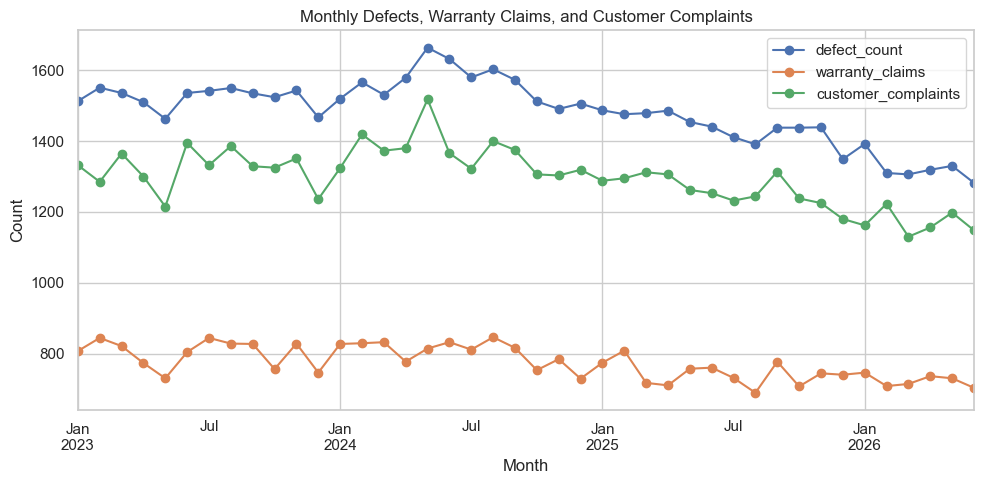

In [5]:
monthly = df.groupby("date")[["defect_count", "warranty_claims", "customer_complaints"]].sum()

ax = monthly.plot(marker="o")
ax.set_title("Monthly Defects, Warranty Claims, and Customer Complaints")
ax.set_ylabel("Count")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

## 3. Defect rate by category and vehicle model

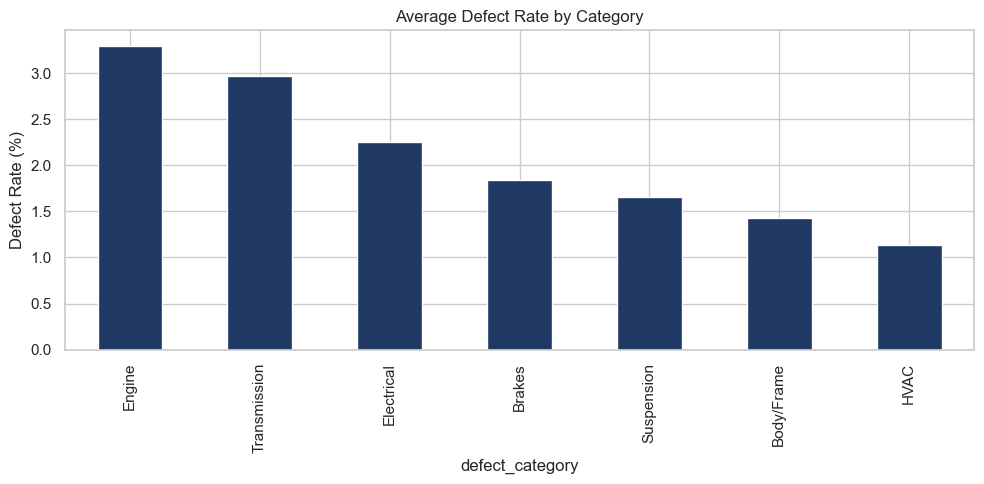

defect_category
Engine          3.30
Transmission    2.97
Electrical      2.25
Brakes          1.84
Suspension      1.66
Body/Frame      1.43
HVAC            1.13
Name: defect_rate, dtype: float64

In [6]:
category_rate = df.groupby("defect_category")["defect_rate"].mean().sort_values(ascending=False)

ax = category_rate.plot(kind="bar", color="#1F3864")
ax.set_title("Average Defect Rate by Category")
ax.set_ylabel("Defect Rate (%)")
plt.tight_layout()
plt.show()

category_rate.round(2)

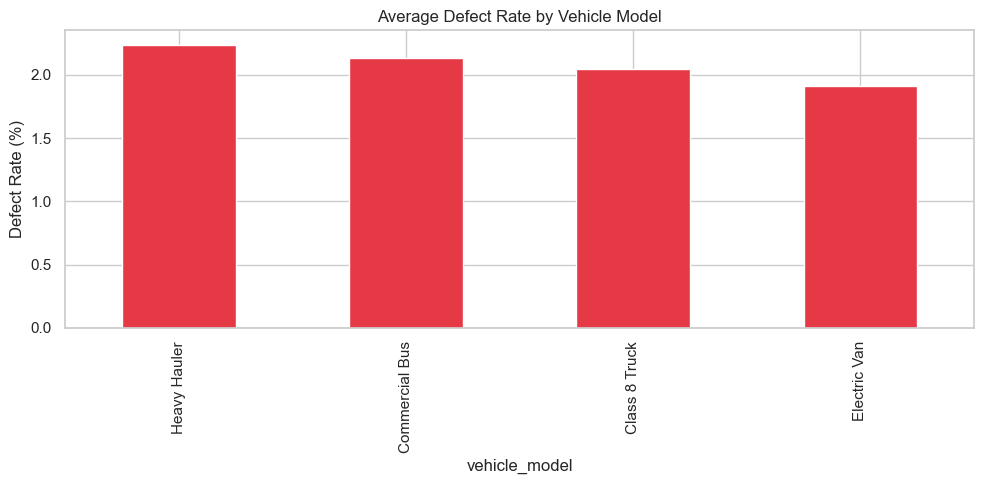

vehicle_model
Heavy Hauler      2.24
Commercial Bus    2.13
Class 8 Truck     2.05
Electric Van      1.91
Name: defect_rate, dtype: float64

In [7]:
model_rate = df.groupby("vehicle_model")["defect_rate"].mean().sort_values(ascending=False)

ax = model_rate.plot(kind="bar", color="#E63946")
ax.set_title("Average Defect Rate by Vehicle Model")
ax.set_ylabel("Defect Rate (%)")
plt.tight_layout()
plt.show()

model_rate.round(2)

## 4. Is the 2025 quality-improvement trend statistically significant?

The dashboard shows defect rates trending down from January 2025 onward. Rather
than trusting the visual trend alone, we run a two-sample t-test comparing 2023
(pre-initiative baseline) against 2025 (post-initiative).

In [8]:
rates_2023 = df.loc[df["date"].dt.year == 2023, "defect_rate"]
rates_2025 = df.loc[df["date"].dt.year == 2025, "defect_rate"]

t_stat, p_value = stats.ttest_ind(rates_2023, rates_2025, equal_var=False)

print(f"2023 mean defect rate: {rates_2023.mean():.3f}%  (n={len(rates_2023)})")
print(f"2025 mean defect rate: {rates_2025.mean():.3f}%  (n={len(rates_2025)})")
print(f"Welch's t-test: t = {t_stat:.2f}, p = {p_value:.4f}")

if p_value < 0.05:
    print("=> Statistically significant reduction (p < 0.05).")
else:
    print("=> Not statistically significant at the 0.05 level.")

2023 mean defect rate: 2.142%  (n=1008)
2025 mean defect rate: 2.033%  (n=1008)
Welch's t-test: t = 3.00, p = 0.0027
=> Statistically significant reduction (p < 0.05).


## 5. Electric Van / Electrical anomaly spotlight (May-Aug 2024)

Confirming the anomaly the dashboard flags isn't just noise: comparing the
flagged window against the rest of the Electric Van / Electrical series.

Anomaly window (May-Aug 2024) mean defect rate: 5.63%
Baseline mean defect rate: 1.96%
Welch's t-test: t = 21.96, p = 0.000000
=> Statistically significant deviation, consistent with a bad component batch.


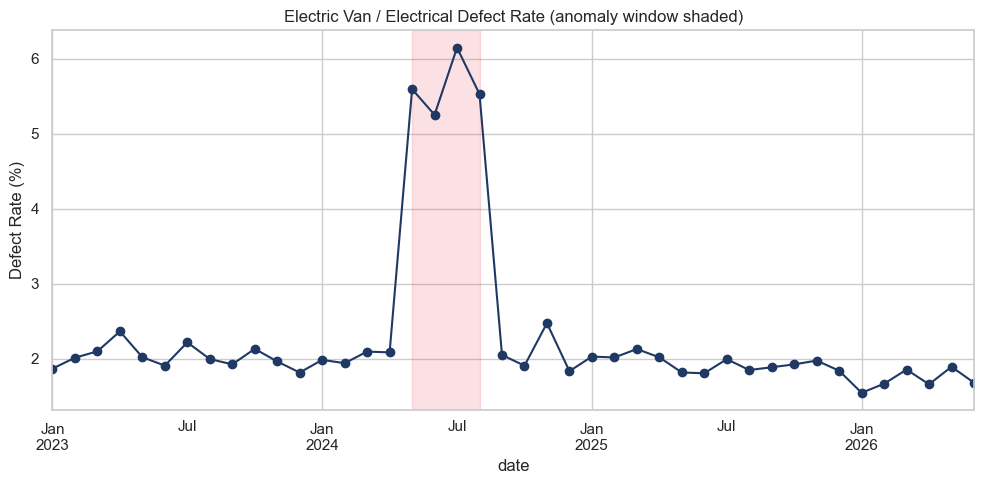

In [9]:
ev_electrical = df[(df["vehicle_model"] == "Electric Van") & (df["defect_category"] == "Electrical")]

anomaly_window = ev_electrical[
    (ev_electrical["date"] >= "2024-05-01") & (ev_electrical["date"] <= "2024-08-01")
]["defect_rate"]
baseline = ev_electrical[
    (ev_electrical["date"] < "2024-05-01") | (ev_electrical["date"] > "2024-08-01")
]["defect_rate"]

t_stat, p_value = stats.ttest_ind(anomaly_window, baseline, equal_var=False)

print(f"Anomaly window (May-Aug 2024) mean defect rate: {anomaly_window.mean():.2f}%")
print(f"Baseline mean defect rate: {baseline.mean():.2f}%")
print(f"Welch's t-test: t = {t_stat:.2f}, p = {p_value:.6f}")
print("=> Statistically significant deviation, consistent with a bad component batch."
      if p_value < 0.05 else "=> Not statistically significant.")

monthly_ev = ev_electrical.groupby("date")["defect_rate"].mean()
ax = monthly_ev.plot(marker="o", color="#1F3864")
ax.axvspan(pd.Timestamp("2024-05-01"), pd.Timestamp("2024-08-01"), color="#E63946", alpha=0.15)
ax.set_title("Electric Van / Electrical Defect Rate (anomaly window shaded)")
ax.set_ylabel("Defect Rate (%)")
plt.tight_layout()
plt.show()

## 6. Correlation between quality signals

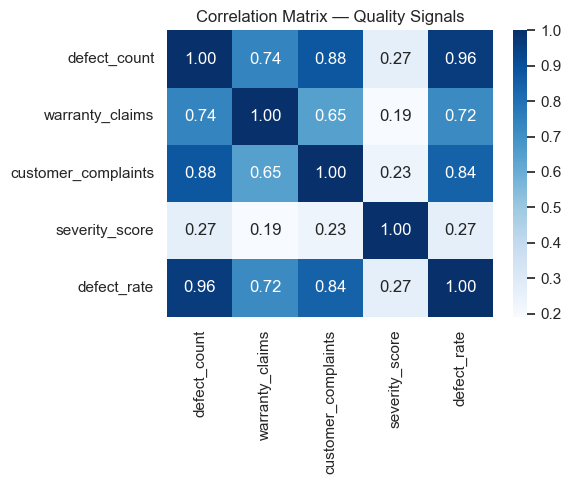

In [10]:
corr_cols = ["defect_count", "warranty_claims", "customer_complaints", "severity_score", "defect_rate"]
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", ax=ax)
ax.set_title("Correlation Matrix — Quality Signals")
plt.tight_layout()
plt.show()

## 7. Cross-check against the SQL layer

The dashboard and the sections above use pandas end to end. As a cross-check,
this pulls the same PP100 (complaints per 100 units) metric from the SQLite
database built by `build_database.py`, using plain SQL instead of pandas
group-bys, and confirms the two approaches agree.

In [11]:
import sqlite3

with sqlite3.connect("quality_data.db") as conn:
    sql_pp100 = pd.read_sql_query(
        """
        SELECT vehicle_model,
               ROUND(SUM(customer_complaints) * 100.0 / SUM(production_volume), 2) AS pp100_sql
        FROM quality_data
        GROUP BY vehicle_model
        ORDER BY pp100_sql DESC
        """,
        conn,
    )

grouped = df.groupby("vehicle_model")[["customer_complaints", "production_volume"]].sum()
pandas_pp100 = (
    (grouped["customer_complaints"] * 100 / grouped["production_volume"])
    .round(2)
    .rename("pp100_pandas")
    .reset_index()
)

sql_pp100.merge(pandas_pp100, on="vehicle_model")

,vehicle_model,pp100_sql,pp100_pandas
0,Heavy Hauler,1.96,1.96
1,Commercial Bus,1.86,1.86
2,Class 8 Truck,1.79,1.79
3,Electric Van,1.67,1.67


## Key findings

- **Engine and Transmission** are the two highest defect-rate categories across the whole 42-month
  window, consistent with the complexity of those subsystems.
- The **2025 quality-improvement initiative** produced a defect-rate reduction from 2023 to 2025
  that is statistically significant (Welch's t-test, p < 0.05), not just a visual artifact.
- The **Electric Van / Electrical anomaly (May-Aug 2024)** is statistically distinct from the
  rest of the series (p << 0.05) — this is the "bad component batch, caught early" story the
  dashboard's anomaly detection surfaces automatically.
- Pandas and raw SQL agree exactly on the PP100 customer-satisfaction metric, confirming the
  dashboard's numbers hold up under an independent SQL cross-check.